In [2]:
%reload_ext autoreload
%autoreload 2

# import all the functions from the fastfeedback module
import iminuit
from fastfeedback import *
from tqdm import tqdm

# Loading the CAFs data

data_manager = DataManager("/storage/1/st15719/caf_new_sum_weighted.root")

# Defining the binning for the true and reco energy and coszenith
Ebins = np.logspace(-1, 1, 200)
Czbins = np.linspace(-1, 1, 100)
Ebins_reco = np.logspace(-1, 1, 50)
Czbins_reco = np.linspace(-1, 1, 20)

latex_names = {
    Flavor.NuE: r"$\nu_e$",
    Flavor.NuMu: r"$\nu_\mu$",
    Flavor.NuMuBar: r"$\bar{\nu}_\mu$",
    Flavor.NuEBar: r"$\bar{\nu}_e$",
    Flavor.NuTau: r"$\bar{\nu}_\tau$",
    Flavor.NuTauBar: r"$\bar{\nu}_\tau$",
}

ktyr = 25

eff_exposure = 160000/ktyr

Loading data...


/software/oz22897/miniconda/envs/dune-atmo-osc/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:454: RuntimeWarning: invalid value encountered in cast
  return self._module.concatenate(arrays, axis=axis, casting="same_kind")


Finished loading data


  0%|          | 0/16 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


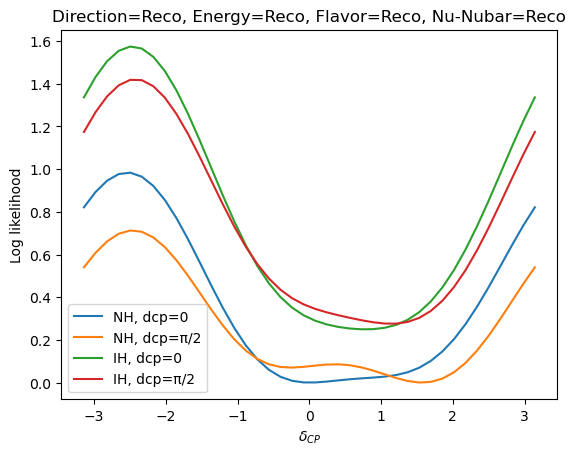

  6%|▋         | 1/16 [00:28<07:09, 28.61s/it]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


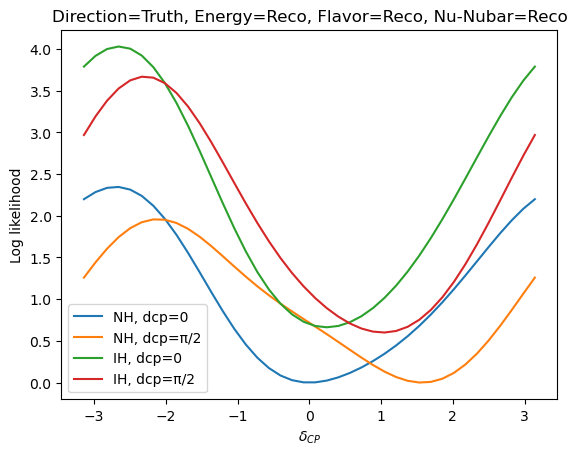

 12%|█▎        | 2/16 [00:50<05:46, 24.73s/it]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


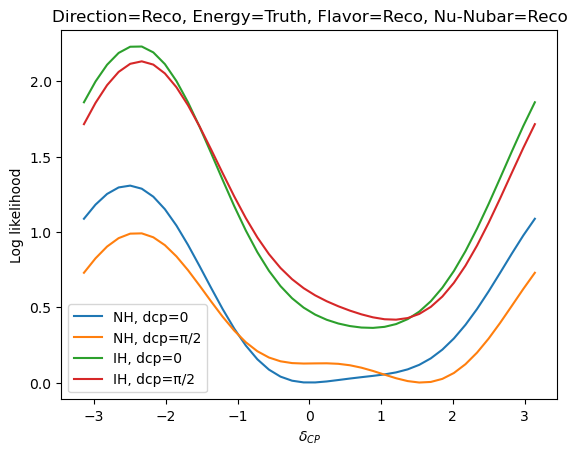

 19%|█▉        | 3/16 [01:14<05:16, 24.36s/it]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


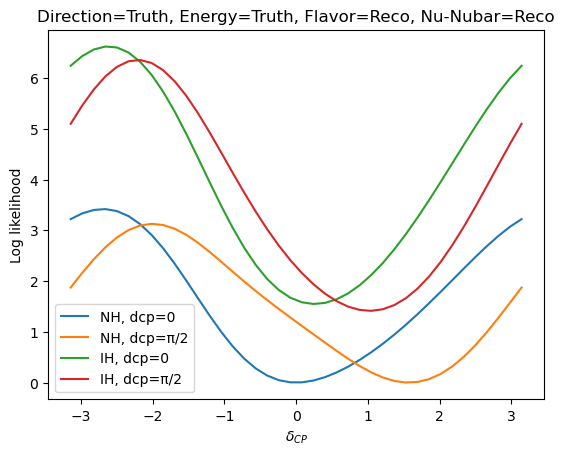

 25%|██▌       | 4/16 [01:34<04:31, 22.65s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


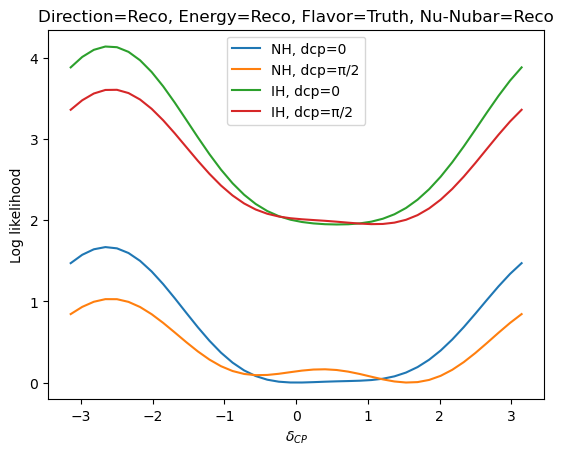

 31%|███▏      | 5/16 [02:11<05:05, 27.82s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


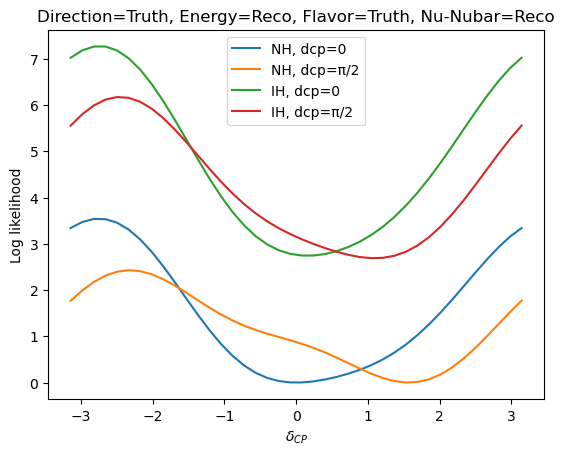

 38%|███▊      | 6/16 [02:45<04:57, 29.75s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


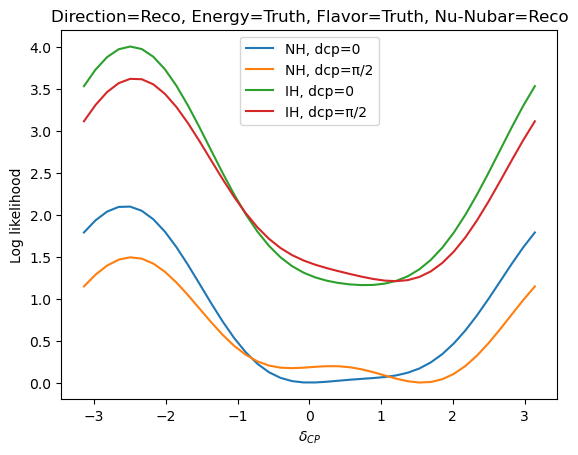

 44%|████▍     | 7/16 [03:20<04:44, 31.66s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


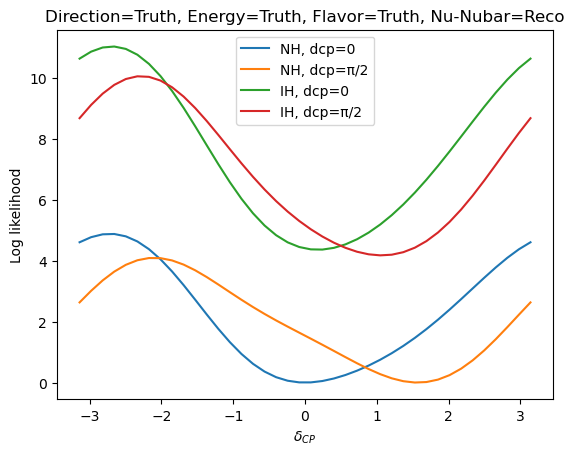

 50%|█████     | 8/16 [03:50<04:08, 31.12s/it]

Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


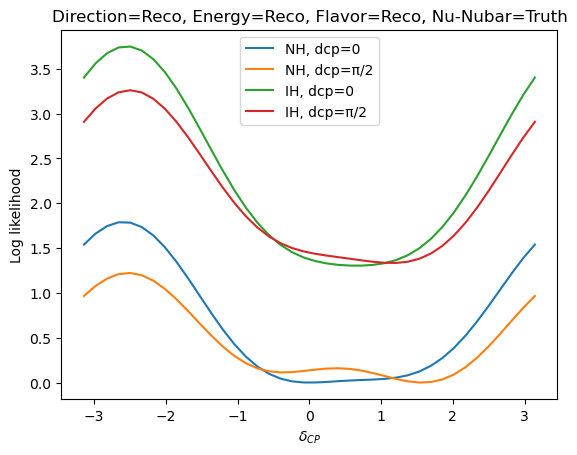

 56%|█████▋    | 9/16 [04:24<03:43, 31.92s/it]

Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


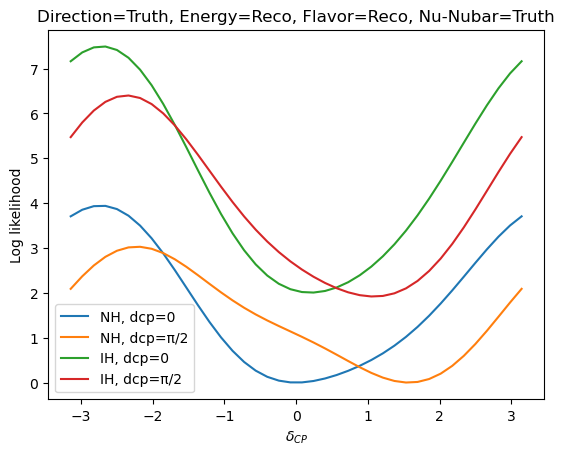

 62%|██████▎   | 10/16 [04:54<03:08, 31.39s/it]

Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


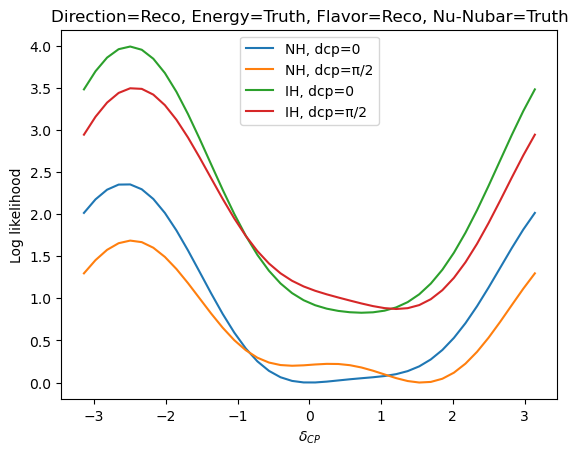

 69%|██████▉   | 11/16 [05:26<02:37, 31.59s/it]

Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


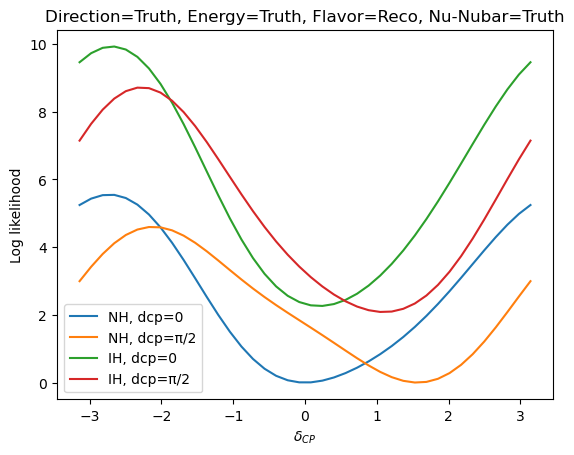

 75%|███████▌  | 12/16 [05:53<02:00, 30.20s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


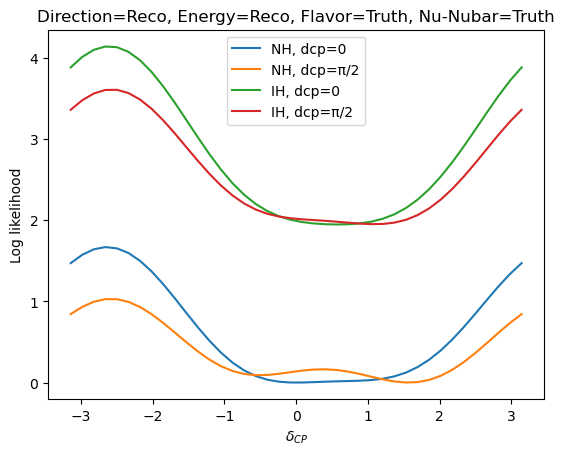

 81%|████████▏ | 13/16 [06:30<01:36, 32.17s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


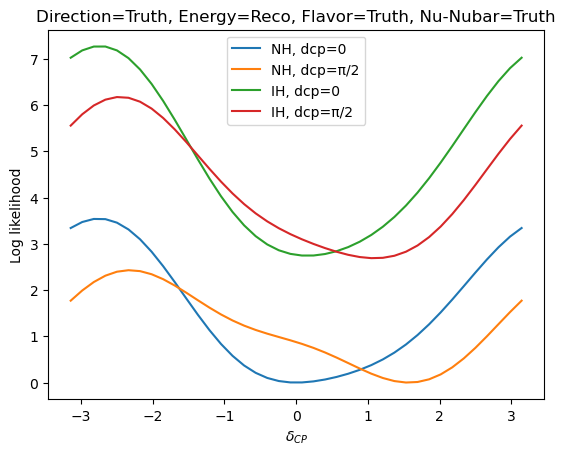

 88%|████████▊ | 14/16 [07:03<01:04, 32.47s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


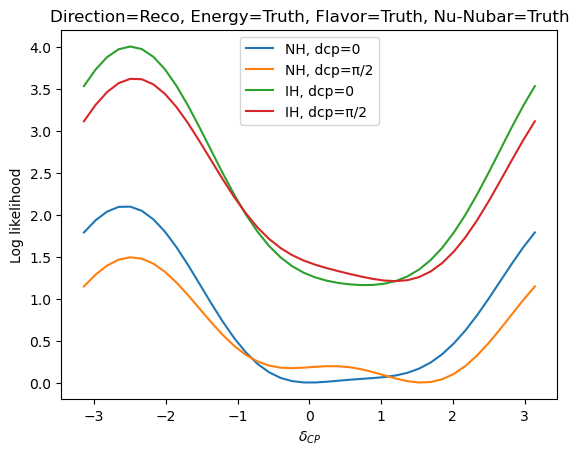

 94%|█████████▍| 15/16 [07:39<00:33, 33.48s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


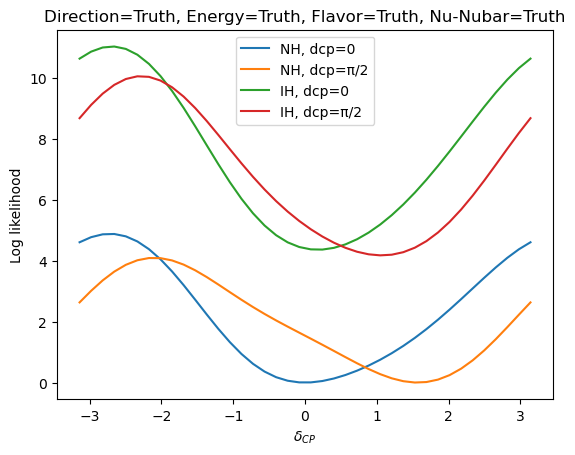

100%|██████████| 16/16 [08:09<00:00, 30.61s/it]


In [4]:
# Preparing the data with the default settings, of the current reco performances
def plot_data(method: int):
    direc_reco = Method.Truth if method & 1 << 0 else Method.Reco
    energy_reco = Method.Truth if method & 1 << 1 else Method.Reco
    flavor_disc = Method.Truth if method & 1 << 2 else Method.Reco
    nunubar_disc = Method.Truth if method & 1 << 3 else Method.Reco

    data_manager.set_direc_reco(direc_reco)
    data_manager.set_energy_reco(energy_reco)
    data_manager.set_flavor_discrimination(flavor_disc)
    data_manager.set_nunubar_discrimination(nunubar_disc)

    data = data_manager.prepare_data()

    # Creating the events distribution
    events = EventDistrib(data, Ebins, Czbins, Ebins_reco, Czbins_reco, exposure = eff_exposure)

    null_hyps = [
        get_nufit(MH.Normal),
        get_nufit(MH.Normal),
        get_nufit(MH.Inverted),
        get_nufit(MH.Inverted),
    ]
    null_hyps[0].dcp = 0
    null_hyps[1].dcp = np.pi / 2
    null_hyps[2].dcp = 0
    null_hyps[3].dcp = np.pi / 2

    ref_event_rates = []

    for null_hyp in null_hyps:
        events.compute_osc(null_hyp)
        ref_event_rates.append(
            {fl: events.detected_events(fl) for fl in events.detected_channels}
        )

    LnL_values_nofit = [[] for _ in range(len(null_hyps))]
    dcp_scan = np.linspace(-np.pi, np.pi, 40)
    for dcp in dcp_scan:
        alt_hyp = get_nufit(MH.Normal)
        alt_hyp.dcp = dcp

        events.compute_osc(alt_hyp)

        expected = {fl: events.detected_events(fl) for fl in events.detected_channels}

        for i, null_hyp in enumerate(null_hyps):
            # Computing the LnL values
            llh = 0
            for ch in events.detected_channels:
                llh += LnL(ref_event_rates[i][ch], expected[ch])
            LnL_values_nofit[i].append(llh)

    plt.figure()
    plt.plot(dcp_scan, LnL_values_nofit[0], label="NH, dcp=0")
    plt.plot(dcp_scan, LnL_values_nofit[1], label="NH, dcp=π/2")
    plt.plot(dcp_scan, LnL_values_nofit[2], label="IH, dcp=0")
    plt.plot(dcp_scan, LnL_values_nofit[3], label="IH, dcp=π/2")

    plt.xlabel(r"$\delta_{CP}$")
    plt.ylabel("Log likelihood")
    plt.title(
        f"Direction={direc_reco.name}, Energy={energy_reco.name}, Flavor={flavor_disc.name}, Nu-Nubar={nunubar_disc.name}"
    )
    plt.legend()
    plt.show()


for i in tqdm(range(0b0000, 0b10000)):
    plot_data(i)

In [5]:
def plot_data(method: int, flavors: dict[Flavor, int | float], plot_sum=True):
    direc_reco = Method.Truth if method & 1 << 0 else Method.Reco
    energy_reco = Method.Truth if method & 1 << 1 else Method.Reco
    flavor_disc = Method.Truth if method & 1 << 2 else Method.Reco

    data_manager.set_direc_reco(direc_reco)
    data_manager.set_energy_reco(energy_reco)
    data_manager.set_flavor_discrimination(flavor_disc)

    efficiencies = {
        Flavor.NuE: flavors.get(Flavor.NuE, 1),
        Flavor.NuEBar: flavors.get(Flavor.NuEBar, 1),
        Flavor.NuMu: flavors.get(Flavor.NuMu, 1),
        Flavor.NuMuBar: flavors.get(Flavor.NuMuBar, 1),
        Flavor.NuTau: flavors.get(Flavor.NuTau, 1),
        Flavor.NuTauBar: flavors.get(Flavor.NuTauBar, 1),
        Flavor.NC: flavors.get(Flavor.NC, 1),
    }
    nunubar = FakeEfficiency(efficiencies)
    data_manager.set_nunubar_discrimination(Method.Efficiency, nunubar)
    data = data_manager.prepare_data()
    events = EventDistrib(data, Ebins, Czbins, Ebins_reco, Czbins_reco, exposure = eff_exposure)

    # Gets the standard oscillation parameters
    pars = get_nufit(MH.Normal)
    # Compute the events with the standard oscillation parameters
    events.compute_osc(pars)
    # Saving the reference event rates
    ref_event_rates = {
        fl: events.detected_events(fl) for fl in events.detected_channels
    }

    LnL_values = {fl: [] for fl in events.detected_channels}

    # Sampling dcp values
    sampling = np.linspace(0, 2 * np.pi, 50)
    for val in sampling:
        # Setting the dcp value
        pars.dcp = val
        # Computing the events with the new dcp value
        events.compute_osc(pars)
        # Saving the expected event rates
        expected = {fl: events.detected_events(fl) for fl in events.detected_channels}

        # Computing the LnL values
        for ch in events.detected_channels:
            LnL_values[ch].append(LnL(ref_event_rates[ch], expected[ch]))

    # Converting the lists to numpy arrays
    LnL_values = {fl: np.array(values) for fl, values in LnL_values.items()}

    sum = 0
    for ch, values in LnL_values.items():
        if ch not in flavors:
            continue

        if plot_sum:
            sum += values

        if len(flavors) == 1:
            plt.plot(
                sampling,
                values,
                label=f"{latex_names[ch]} Dir={direc_reco.name[0]}, E={energy_reco.name[0]}, Fl={flavor_disc.name[0]}",
            )
        else:
            plt.plot(sampling, values, label=latex_names[ch])

    if plot_sum:
        plt.plot(sampling, sum, label="Sum")
    plt.xlabel(r"$\delta_{CP}$")
    plt.ylabel("Log likelihood")
    if len(flavors) > 1:
        plt.title(
            f"Direction={direc_reco.name}, Energy={energy_reco.name}, Flavor={flavor_disc.name}"
        )
    plt.legend()

  0%|          | 0/8 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


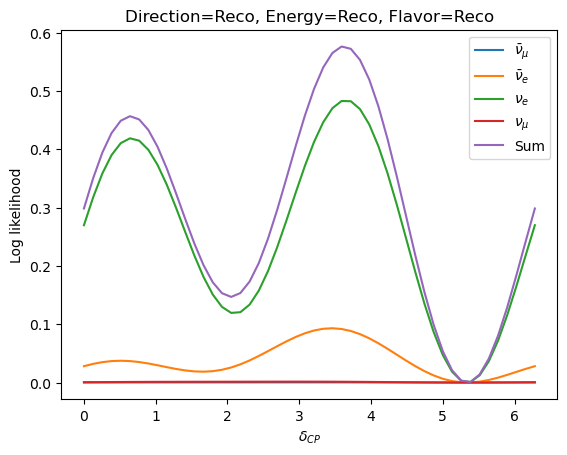

 12%|█▎        | 1/8 [00:31<03:41, 31.68s/it]

Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


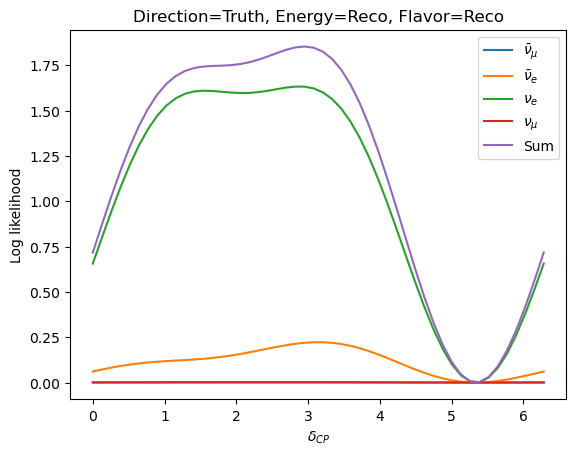

 25%|██▌       | 2/8 [00:59<02:55, 29.19s/it]

Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


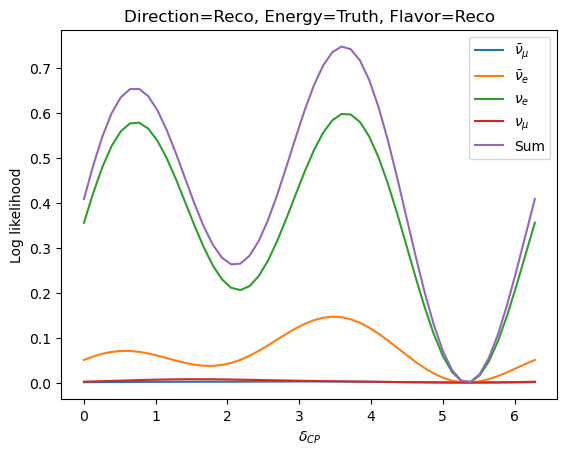

 38%|███▊      | 3/8 [01:29<02:28, 29.63s/it]

Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


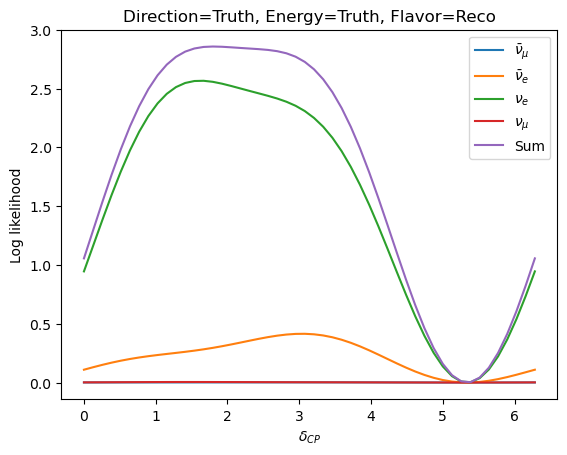

 50%|█████     | 4/8 [01:53<01:50, 27.55s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


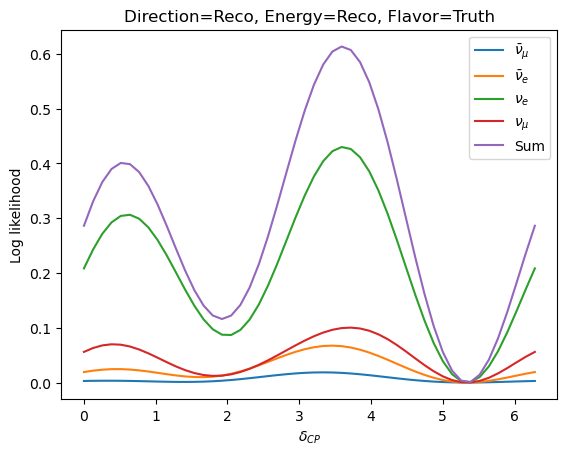

 62%|██████▎   | 5/8 [02:27<01:29, 29.77s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


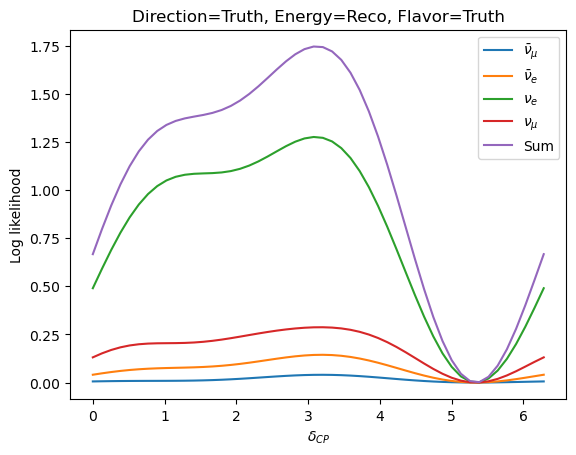

 75%|███████▌  | 6/8 [02:57<00:59, 29.93s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


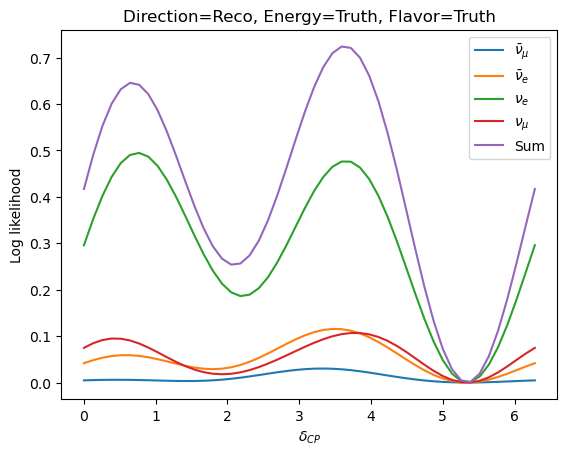

 88%|████████▊ | 7/8 [03:30<00:30, 30.86s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


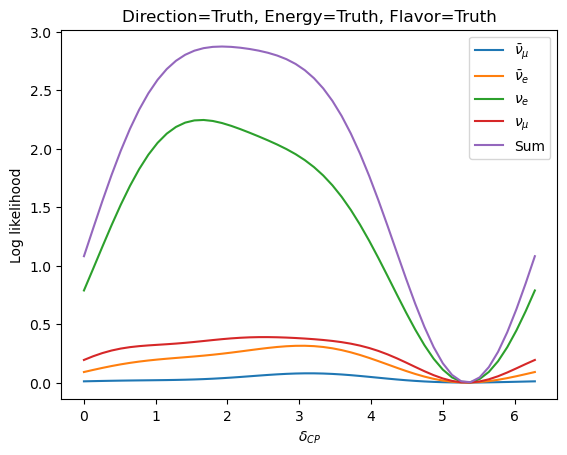

100%|██████████| 8/8 [03:56<00:00, 29.58s/it]


In [6]:
for i in tqdm(range(0b000, 0b1000)):
    plt.figure()
    plot_data(i, {Flavor.NuE: 1, Flavor.NuEBar: 1, Flavor.NuMu: 1, Flavor.NuMuBar: 1})
    plt.show()

  0%|          | 0/8 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


 12%|█▎        | 1/8 [00:31<03:39, 31.34s/it]

Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


 25%|██▌       | 2/8 [00:59<02:55, 29.19s/it]

...

 75%|███████▌  | 6/8 [02:57<01:00, 30.00s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


 88%|████████▊ | 7/8 [03:30<00:30, 30.79s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


100%|██████████| 8/8 [03:56<00:00, 29.53s/it]


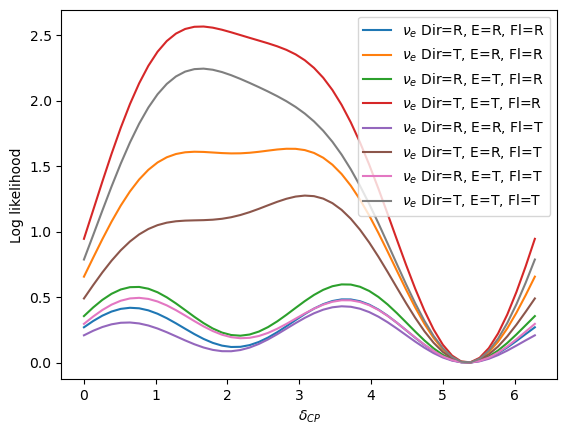

In [7]:
plt.figure()
for i in tqdm(range(0b000, 0b1000)):
    plot_data(i, {Flavor.NuE: 1}, False)
plt.show()

  0%|          | 0/16 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


  6%|▋         | 1/16 [00:54<13:43, 54.92s/it]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


 12%|█▎        | 2/16 [01:37<11:08, 47.73s/it]

...

 88%|████████▊ | 14/16 [12:26<01:52, 56.25s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


 94%|█████████▍| 15/16 [13:27<00:57, 57.58s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


100%|██████████| 16/16 [14:14<00:00, 53.38s/it]


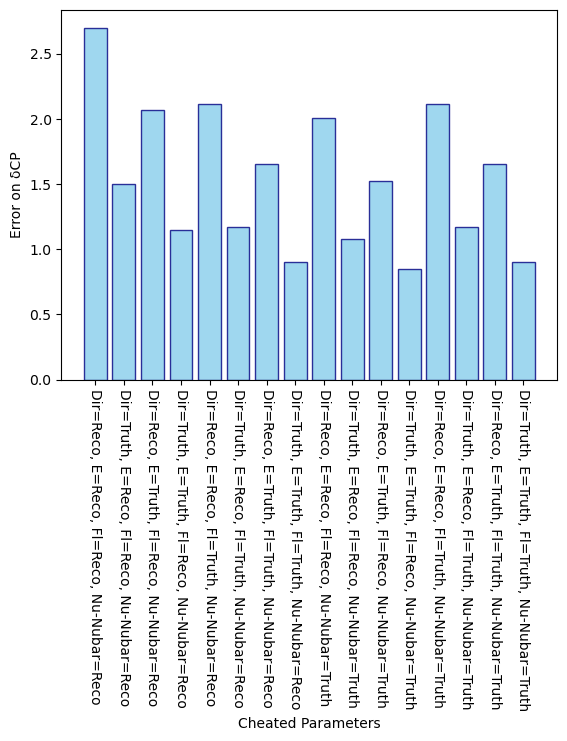

In [8]:
results = []

def plot_data(method: int):
    direc_reco = Method.Truth if method & 1 << 0 else Method.Reco
    energy_reco = Method.Truth if method & 1 << 1 else Method.Reco
    flavor_disc = Method.Truth if method & 1 << 2 else Method.Reco
    nunubar_disc = Method.Truth if method & 1 << 3 else Method.Reco

    data_manager.set_direc_reco(direc_reco)
    data_manager.set_energy_reco(energy_reco)
    data_manager.set_flavor_discrimination(flavor_disc)
    data_manager.set_nunubar_discrimination(nunubar_disc)

    data = data_manager.prepare_data()

    # Creating the events distribution
    events = EventDistrib(data, Ebins, Czbins, Ebins_reco, Czbins_reco, exposure = eff_exposure)

    # Gets the standard oscillation parameters
    pars = get_nufit(MH.Normal)
    # Compute the events with the standard oscillation parameters
    events.compute_osc(pars)
    # Saving the reference event rates
    ref_event_rates = {
        fl: events.detected_events(fl) for fl in events.detected_channels
    }

    LnL_values = {fl: [] for fl in events.detected_channels}

    # Sampling dcp values
    sampling = np.linspace(0, 2 * np.pi, 50)
    for val in sampling:
        # Setting the dcp value
        pars.dcp = val
        # Computing the events with the new dcp value
        events.compute_osc(pars)
        # Saving the expected event rates
        expected = {fl: events.detected_events(fl) for fl in events.detected_channels}

        # Computing the LnL values
        for ch in events.detected_channels:
            LnL_values[ch].append(LnL(ref_event_rates[ch], expected[ch]))

    # Converting the lists to numpy arrays
    LnL_values = {fl: np.array(values) for fl, values in LnL_values.items()}

    def loss(dm21, dm31, th12, th13, th23, dcp):
        pars = ROOT.OscPars()
        pars.dm21 = dm21
        pars.dm31 = dm31
        pars.th12 = th12
        pars.th13 = th13
        pars.th23 = th23
        pars.dcp = dcp

        events.compute_osc(pars)
        # Saving the expected event rates
        expected = {fl: events.detected_events(fl) for fl in events.detected_channels}
        total_loss = 0
        for ch in events.detected_channels:
            total_loss += LnL(ref_event_rates[ch], expected[ch])
        # print(total_loss)
        return total_loss

    nufit = get_nufit(MH.Normal)

    fitter = iminuit.Minuit(
        loss,
        dm21=nufit.dm21,
        dm31=nufit.dm31,
        th12=nufit.th12,
        th13=nufit.th13,
        th23=nufit.th23,
        dcp=nufit.dcp,
    )

    dcp_err = fitter.hesse().errors["dcp"]
    best_fit_dcp = fitter.values["dcp"]

    results.append({
        "Method_ID": bin(method),
        "Direction": direc_reco.name,
        "Energy": energy_reco.name,
        "Flavor": flavor_disc.name,
        "Nu_Nubar": nunubar_disc.name,
        "dCP_BestFit": best_fit_dcp,
        "dCP_Error": dcp_err
    })


    plt.bar(
        f"Dir={direc_reco.name}, E={energy_reco.name}, Fl={flavor_disc.name}, Nu-Nubar={nunubar_disc.name}",
        dcp_err, color='skyblue', edgecolor='navy', alpha=0.8
    )
    plt.xticks(rotation=-90)


plt.figure()
plt.xlabel("Cheated Parameters")
plt.ylabel("Error on δCP")
for i in tqdm(range(0b0000, 0b10000)):
    plot_data(i)
plt.show()

In [9]:
df = pd.DataFrame(results)
df

,Method_ID,Direction,Energy,Flavor,Nu_Nubar,dCP_BestFit,dCP_Error
0,0b0,Reco,Reco,Reco,Reco,5.340708,2.701521
1,0b1,Truth,Reco,Reco,Reco,5.340708,1.502289
2,0b10,Reco,Truth,Reco,Reco,5.340708,2.066289
3,0b11,Truth,Truth,Reco,Reco,5.340708,1.145469
4,0b100,Reco,Reco,Truth,Reco,5.340708,2.115761
5,0b101,Truth,Reco,Truth,Reco,5.340708,1.174983
6,0b110,Reco,Truth,Truth,Reco,5.340708,1.657449
7,0b111,Truth,Truth,Truth,Reco,5.340708,0.900920
8,0b1000,Reco,Reco,Reco,Truth,5.340708,2.006706
9,0b1001,Truth,Reco,Reco,Truth,5.340708,1.079173


  0%|          | 0/11 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


  9%|▉         | 1/11 [00:31<05:16, 31.63s/it]

Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


 18%|█▊        | 2/11 [01:03<04:46, 31.79s/it]

...

 82%|████████▏ | 9/11 [04:46<01:03, 31.83s/it]

Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


 91%|█████████ | 10/11 [05:18<00:31, 31.99s/it]

Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


100%|██████████| 11/11 [05:50<00:00, 31.86s/it]


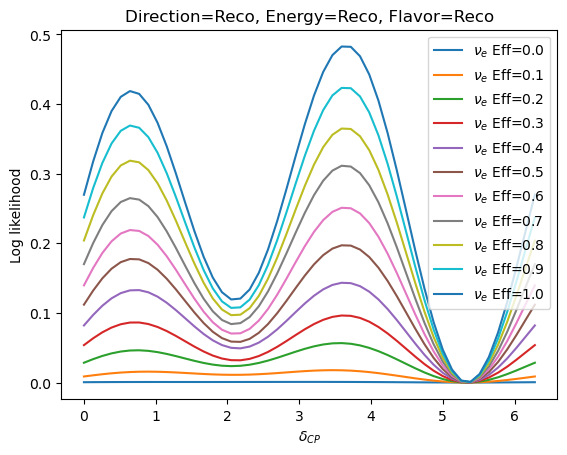

  0%|          | 0/11 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuMu', 'NuTau']
Finished filling histograms...


  9%|▉         | 1/11 [00:22<03:42, 22.26s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


 18%|█▊        | 2/11 [00:47<03:38, 24.28s/it]

...

 82%|████████▏ | 9/11 [03:53<00:52, 26.34s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


 91%|█████████ | 10/11 [04:19<00:26, 26.37s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


100%|██████████| 11/11 [04:45<00:00, 25.96s/it]


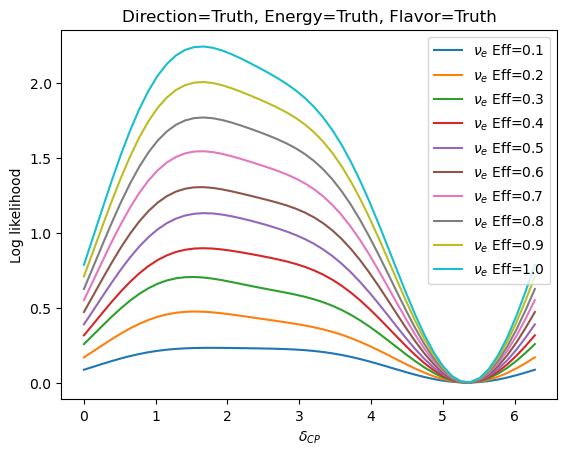

In [5]:
# Reco llh efficienies scan 25 ktyr 

def plot_nunubar_efficiencies(method: int, flavors: dict[Flavor, int | float]):
    direc_reco = Method.Truth if method & 1 << 0 else Method.Reco
    energy_reco = Method.Truth if method & 1 << 1 else Method.Reco
    flavor_disc = Method.Truth if method & 1 << 2 else Method.Reco

    data_manager.set_direc_reco(direc_reco)
    data_manager.set_energy_reco(energy_reco)
    data_manager.set_flavor_discrimination(flavor_disc)

    efficiencies = {
        Flavor.NuE: flavors.get(Flavor.NuE, 1.0),
        Flavor.NuEBar: flavors.get(Flavor.NuEBar, 1.0),
        Flavor.NuMu: flavors.get(Flavor.NuMu, 1.0),
        Flavor.NuMuBar: flavors.get(Flavor.NuMuBar, 1.0),
        Flavor.NuTau: flavors.get(Flavor.NuTau, 1.0),
        Flavor.NuTauBar: flavors.get(Flavor.NuTauBar, 1.0),
        Flavor.NC: flavors.get(Flavor.NC, 1.0),
    }
    nunubar = FakeEfficiency(efficiencies)
    data_manager.set_nunubar_discrimination(Method.Efficiency, nunubar)
    data = data_manager.prepare_data()
    events = EventDistrib(data, Ebins, Czbins, Ebins_reco, Czbins_reco, exposure = eff_exposure)

    # Gets the standard oscillation parameters
    pars = get_nufit(MH.Normal)
    # Compute the events with the standard oscillation parameters
    events.compute_osc(pars)
    # Saving the reference event rates
    ref_event_rates = {
        fl: events.detected_events(fl) for fl in events.detected_channels
    }

    LnL_values = {fl: [] for fl in events.detected_channels}

    # Sampling dcp values
    sampling = np.linspace(0, 2 * np.pi, 50)
    for val in sampling:
        # Setting the dcp value
        pars.dcp = val
        # Computing the events with the new dcp value
        events.compute_osc(pars)
        # Saving the expected event rates
        expected = {fl: events.detected_events(fl) for fl in events.detected_channels}

        # Computing the LnL values
        for ch in events.detected_channels:
            LnL_values[ch].append(LnL(ref_event_rates[ch], expected[ch]))

    # Converting the lists to numpy arrays
    LnL_values = {fl: np.array(values) for fl, values in LnL_values.items()}

    for ch, values in LnL_values.items():
        if ch not in flavors:
            continue

        plt.plot(
            sampling,
            values,
            label=f"{latex_names[ch]} Eff={efficiencies[ch]:.1f}",
        )

    plt.xlabel(r"$\delta_{CP}$")
    plt.ylabel("Log likelihood")
    plt.title(
        f"Direction={direc_reco.name}, Energy={energy_reco.name}, Flavor={flavor_disc.name}"
    )


for method in [0b000, 0b111]:  # [all reco, all truth]
    plt.figure()
    for efficiency in tqdm(np.linspace(0, 1, 11)):
        plot_nunubar_efficiencies(method, {Flavor.NuE: efficiency})
    plt.legend()
    plt.show()

  0%|          | 0/11 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


  9%|▉         | 1/11 [01:04<10:40, 64.08s/it]

Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


 18%|█▊        | 2/11 [02:08<09:39, 64.40s/it]

...

 82%|████████▏ | 9/11 [09:37<02:08, 64.23s/it]

Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


 91%|█████████ | 10/11 [10:40<01:03, 63.80s/it]

Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


100%|██████████| 11/11 [11:42<00:00, 63.84s/it]


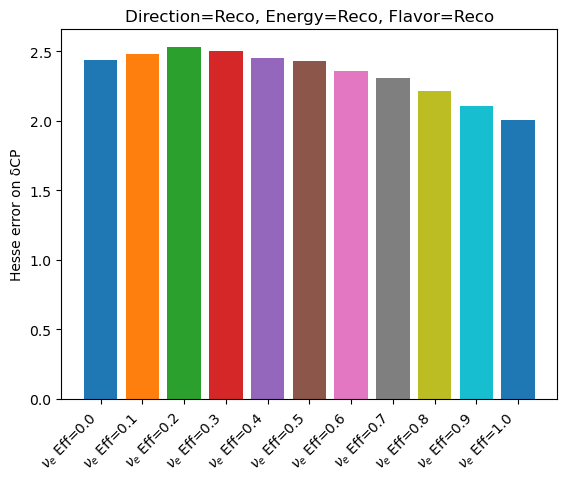

  0%|          | 0/11 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuMu', 'NuTau']
Finished filling histograms...


  9%|▉         | 1/11 [00:39<06:34, 39.45s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


 18%|█▊        | 2/11 [01:24<06:26, 42.97s/it]

...

 82%|████████▏ | 9/11 [06:48<01:32, 46.09s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


 91%|█████████ | 10/11 [07:34<00:45, 45.99s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


100%|██████████| 11/11 [08:20<00:00, 45.46s/it]


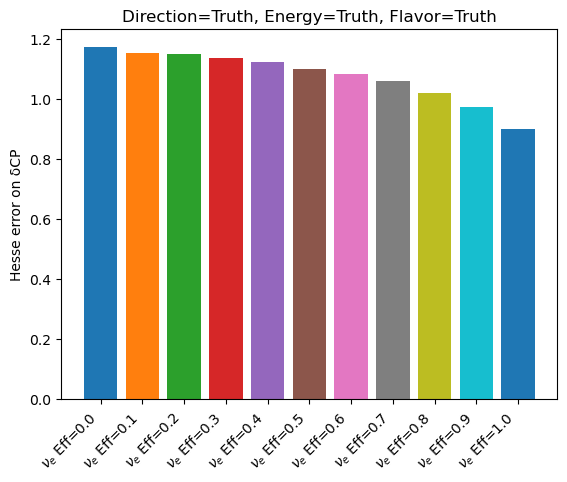

In [6]:
# All Reco and all Truth, dcp error efficiencies scan 25 kt yr

def plot_hesse_errors_nunubar_eff(
    method: int, flavor=Flavor.NuE, efficiency: float = 1.0
):
    direc_reco = Method.Truth if method & 1 << 0 else Method.Reco
    energy_reco = Method.Truth if method & 1 << 1 else Method.Reco
    flavor_disc = Method.Truth if method & 1 << 2 else Method.Reco

    data_manager.set_direc_reco(direc_reco)
    data_manager.set_energy_reco(energy_reco)
    data_manager.set_flavor_discrimination(flavor_disc)

    efficiencies = {
        Flavor.NuE: 1.0,
        Flavor.NuEBar: 1.0,
        Flavor.NuMu: 1.0,
        Flavor.NuMuBar: 1.0,
        Flavor.NuTau: 1.0,
        Flavor.NuTauBar: 1.0,
        Flavor.NC: 1.0,
    }
    efficiencies[flavor] = efficiency

    nunubar = FakeEfficiency(efficiencies)
    data_manager.set_nunubar_discrimination(Method.Efficiency, nunubar)
    data = data_manager.prepare_data()

    # Creating the events distribution
    events = EventDistrib(data, Ebins, Czbins, Ebins_reco, Czbins_reco, exposure = eff_exposure)

    # Gets the standard oscillation parameters
    pars = get_nufit(MH.Normal)
    # Compute the events with the standard oscillation parameters
    events.compute_osc(pars)
    # Saving the reference event rates
    ref_event_rates = {
        fl: events.detected_events(fl) for fl in events.detected_channels
    }

    LnL_values = {fl: [] for fl in events.detected_channels}

    # Sampling dcp values
    sampling = np.linspace(0, 2 * np.pi, 50)
    for val in sampling:
        # Setting the dcp value
        pars.dcp = val
        # Computing the events with the new dcp value
        events.compute_osc(pars)
        # Saving the expected event rates
        expected = {fl: events.detected_events(fl) for fl in events.detected_channels}

        # Computing the LnL values
        for ch in events.detected_channels:
            LnL_values[ch].append(LnL(ref_event_rates[ch], expected[ch]))

    # Converting the lists to numpy arrays
    LnL_values = {fl: np.array(values) for fl, values in LnL_values.items()}

    def loss(dm21, dm31, th12, th13, th23, dcp):
        pars = ROOT.OscPars()
        pars.dm21 = dm21
        pars.dm31 = dm31
        pars.th12 = th12
        pars.th13 = th13
        pars.th23 = th23
        pars.dcp = dcp

        events.compute_osc(pars)
        # Saving the expected event rates
        expected = {fl: events.detected_events(fl) for fl in events.detected_channels}
        total_loss = 0
        for ch in events.detected_channels:
            total_loss += LnL(ref_event_rates[ch], expected[ch])
        # print(total_loss)
        return total_loss

    nufit = get_nufit(MH.Normal)

    fitter = iminuit.Minuit(
        loss,
        dm21=nufit.dm21,
        dm31=nufit.dm31,
        th12=nufit.th12,
        th13=nufit.th13,
        th23=nufit.th23,
        dcp=nufit.dcp,
    )

    dcp_err = fitter.hesse().errors["dcp"]
    plt.bar(
        f"{latex_names[flavor]} Eff={efficiencies[flavor]:.1f}",
        dcp_err,
    )
    plt.xticks(rotation=45, ha="right")
    plt.title(
        f"Direction={direc_reco.name}, Energy={energy_reco.name}, Flavor={flavor_disc.name}"
    )
    plt.ylabel("Hesse error on δCP")


for method in [0b000, 0b111]:
    plt.figure()
    for efficiency in tqdm(np.linspace(0, 1, 11)):
        plot_hesse_errors_nunubar_eff(method, Flavor.NuE, efficiency)
    plt.show()